In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import ase
import abtem
from pathlib import Path
import matplotlib.pyplot as plt

# Building ABTEM Potentials and Zooming/Cropping into ROIs
*Cedric Lim, 10/28/25*

- Each gold nanoparticle is rotated at different orientatons, and embedded at different z-heights into the carbon substrate.

In [3]:
# Loading ASE atoms

system = ase.io.read('../data/au_np_system.xyz')

In [ ]:
abtem.show_atoms(system, scale = 1, plane = 'xz')

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x700703a45550>>
Traceback (most recent call last):
  File "/home/cedlim/miniforge3/envs/tomo-sparse/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


# Building Potentials

[########################################] | 100% Completed | 932.70 ms


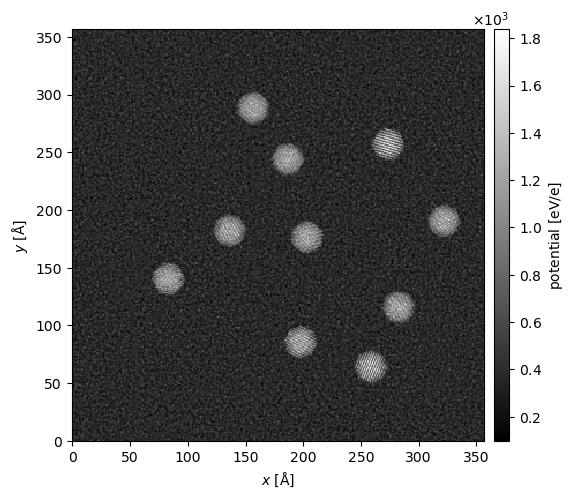

In [4]:
# Multislice simulation to build potential

potential = abtem.Potential(
    system,
    sampling = 1,
    projection = 'infinite',
    slice_thickness = 1,
    device = 'gpu'
).build()

potential.show(cbar = True, cmap = 'gray')


(np.float64(-0.5), np.float64(356.5), np.float64(356.5), np.float64(-0.5))

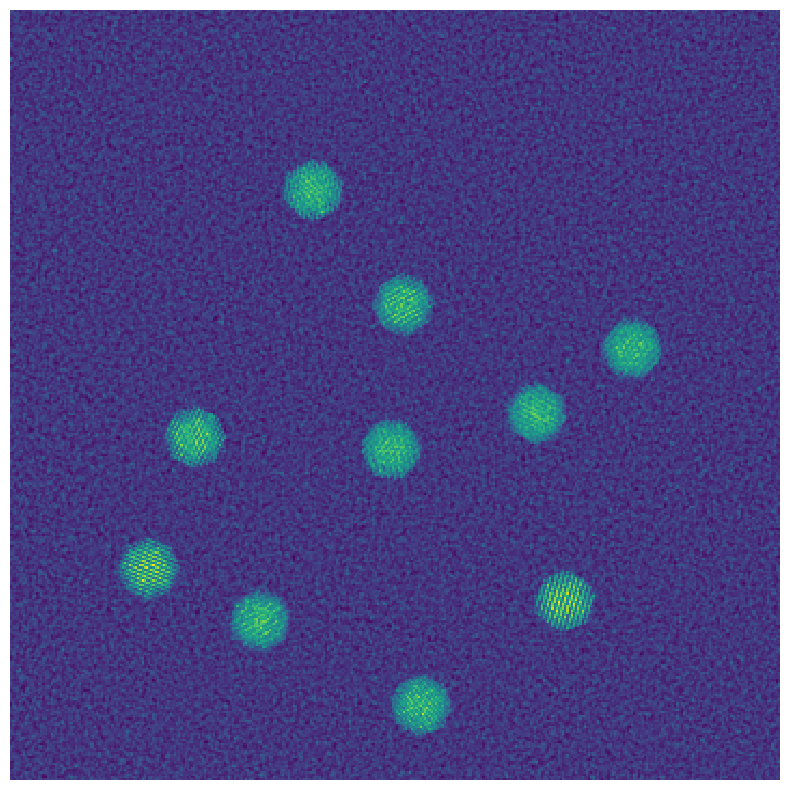

In [5]:
fig, ax = plt.subplots(figsize = (15, 10))
ax.matshow(potential.array.compute().sum(axis = 0).get())
ax.axis('off')

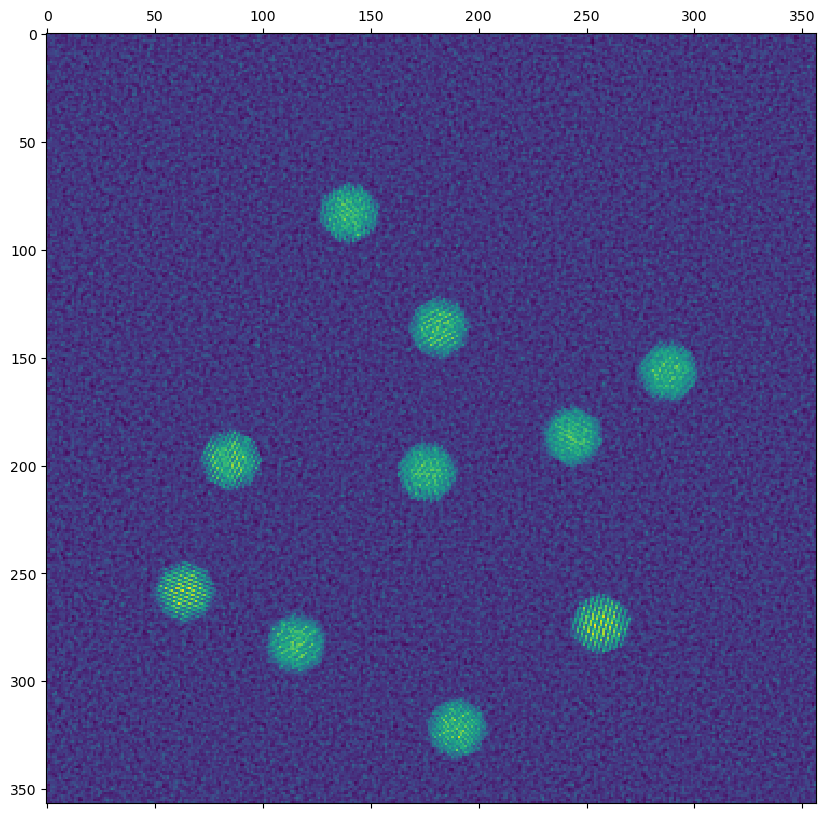

In [7]:
fig, ax = plt.subplots(figsize = (15, 10))

ax.matshow(potential.array.compute().sum(axis = 0).get())

# Tilt Series

In [7]:
def crop_region(system, center_x, center_y, crop_size, padding=25):

    # Compute crop bounds
    x_min, x_max = center_x - crop_size/2 - padding, center_x + crop_size/2 + padding
    y_min, y_max = center_y - crop_size/2 - padding, center_y + crop_size/2 + padding

    # Select atoms in region
    positions = system.positions
    mask = (
        (positions[:, 0] >= x_min) &
        (positions[:, 0] <= x_max) &
        (positions[:, 1] >= y_min) &
        (positions[:, 1] <= y_max)
    )
    cropped = system[mask]

    # Define new in-plane cell
    cell = system.cell.copy()
    cell[0, 0] = crop_size + 2 * padding
    cell[1, 1] = crop_size + 2 * padding
    cropped.set_cell(cell)

    # Recenter within x–y plane
    cropped.center(axis=(0, 1))  # keep z fixed

    return cropped


def find_center_of_mass(system):
    numbers = np.array(system.get_atomic_numbers())
    au_mask = numbers == 79
    return np.mean(system[au_mask].positions, axis=0)





In [96]:
# --- usage ---
test = crop_region(system, 185, 250, 50, padding = 0)

# Take out substrate
numbers = np.array(test.get_atomic_numbers())
# au_mask = numbers == 79
# test = test[au_mask]
test = test

test_com = find_center_of_mass(test)

# Shift atoms so Au COM is at cell center (not origin)
cell_center = test.cell.sum(axis=0) / 2  # geometric center of cell
shift_vec = test_com - cell_center

test.positions -= shift_vec  # shift both Au and C down so Au COM is centered
test.rotate(35, 'y', center = 'COM')
# test.positions -=
# test.center()


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='y [Å]', ylabel='z [Å]'>)

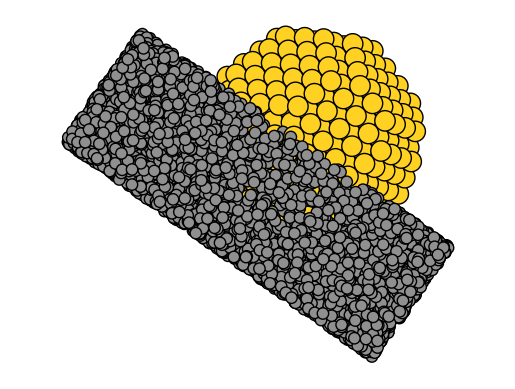

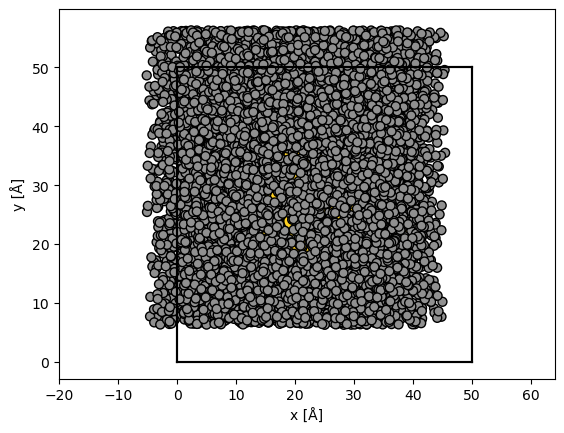

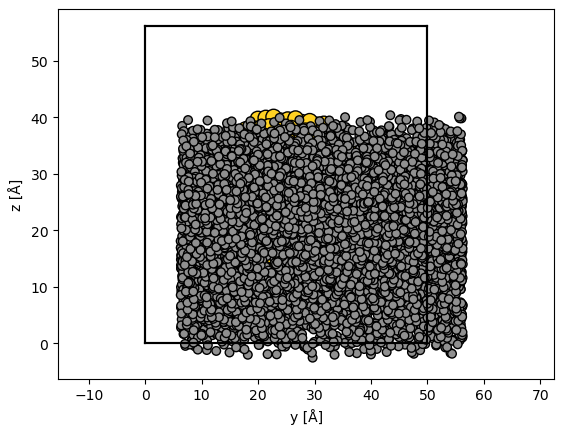

In [97]:
fig, ax = abtem.show_atoms(test, scale = 1, plane = 'xz', show_cell = False)
ax.axis('off')

fig.savefig('potential_0_xz.pdf', dpi = 300)
abtem.show_atoms(test, scale = 1, plane = 'xy')
abtem.show_atoms(test, scale = 1, plane = 'yz')



In [56]:
from scipy.ndimage import gaussian_filter

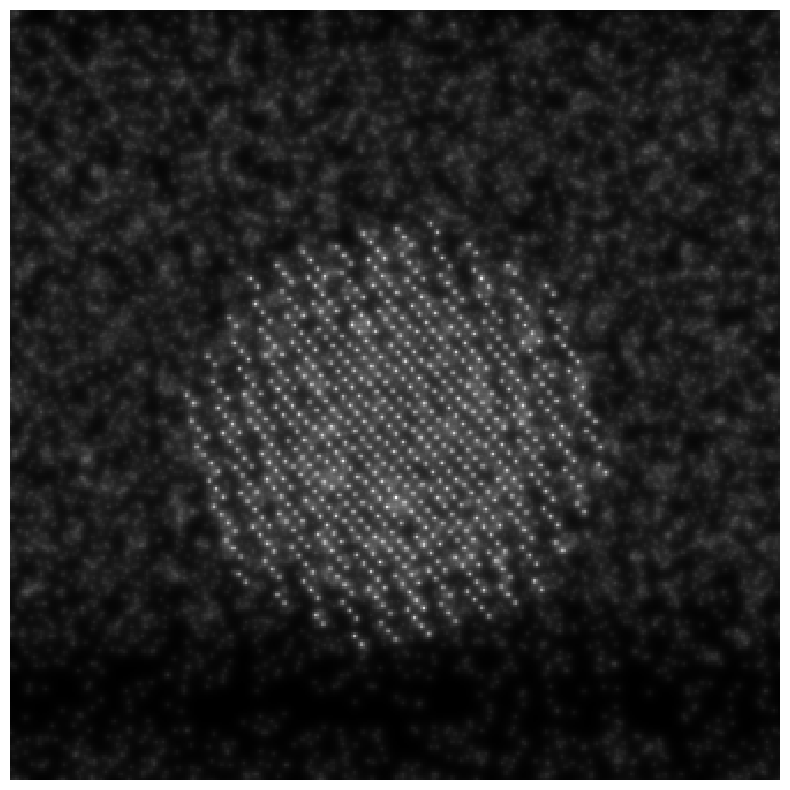

In [98]:
potential = abtem.Potential(
    test,
    sampling = 0.15,
    projection = 'infinite',
    slice_thickness = 1,
    device = 'gpu'
).build()
potential = gaussian_filter(potential.array.compute().get().sum(axis = 0), sigma = 0)
# potential.show(cbar = True, cmap = 'gray')

fig, ax = plt.subplots(figsize = (10, 10))
ax.matshow(potential, cmap = 'gray')
ax.axis('off')
fig.savefig('potential_1_focused.pdf', dpi = 300)


In [143]:
test.rotate(45, 'y',center = 'COM')

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

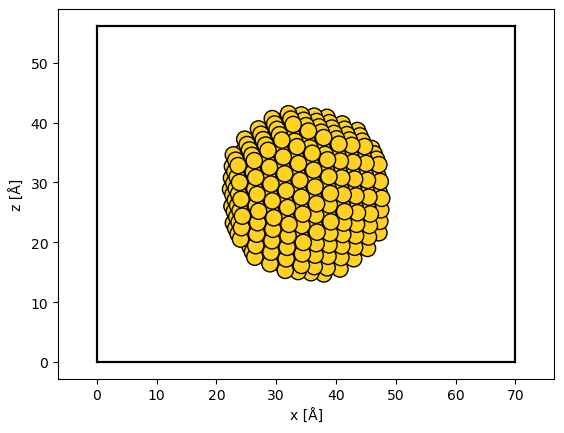

In [144]:
abtem.show_atoms(test, scale = 1, plane = 'xz')

[########################################] | 100% Completed | 101.85 ms


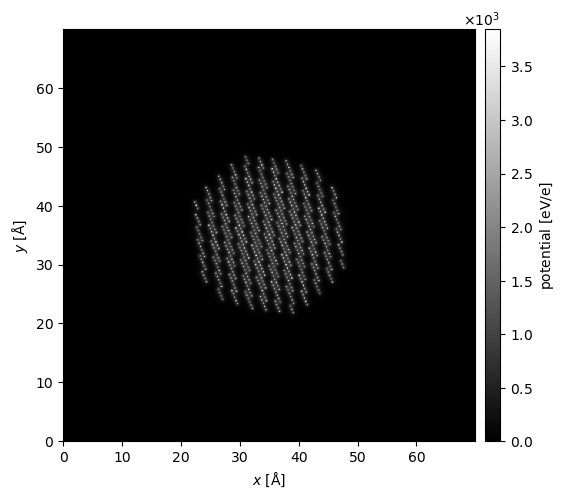

In [145]:
potential = abtem.Potential(
    test,
    sampling = 0.1,
    projection = 'infinite',
    slice_thickness = 1,
    device = 'gpu'
).build()

potential.show(cbar = True, cmap = 'gray')

In [149]:
tilt_angles = np.arange(-70, 71, 10)
len(tilt_angles)

15

In [169]:
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm
import numpy as np
import abtem

# --------------------------------------------
# Define tilt sequence
# --------------------------------------------
tilt_angles = np.arange(-70, 71, 1)
tilt_steps = np.diff(tilt_angles)  # step differences, typically 1°
tilt_steps = np.concatenate([[0], tilt_steps])
# print(tilt_steps.shape)
# print(tilt_steps)
tilt_series = []
potentials = []

# --------------------------------------------
# Define a global set of reference orientation vectors (like before)
# --------------------------------------------
Ovec_global = np.array([
    [0, 0, 1],
    [0, 1, 0],
    [0, 0, 1],
    [1, 1, 1],
], dtype=float)
Ovec_global = Ovec_global / np.linalg.norm(Ovec_global, axis=1)[:, None]

# --------------------------------------------
# Apply initial rotation using rotation-vector method
# --------------------------------------------
init_angle = -70
theta_start = 90  # rotation about y-axis corresponds to ZXZ's middle rotation

# Initial rotation operator
Rvec_init = R.from_rotvec([
    init_angle * np.cos(np.deg2rad(theta_start)),
    init_angle * np.sin(np.deg2rad(theta_start)),
    0,
], degrees=True)

# Rotate the global orientation vectors
Ovec = Rvec_init.apply(Ovec_global)

# Apply same rotation to structure
test_rot = test.copy()
test_rot.rotate(
    init_angle,
    [np.cos(np.deg2rad(theta_start)), np.sin(np.deg2rad(theta_start)), 0],
    center='COM'
)
test_rot.center()

# Add to tilt series
# tilt_series.append(test_rot)
phi_prev = init_angle

# --------------------------------------------
# Loop through tilt increments using ZXZ-style rotation vectors
# --------------------------------------------
for i, delta_phi in enumerate(tqdm(tilt_steps)):
    theta = 90  # tilt axis: rotation about y-axis
    # Incremental rotation (relative)
    Rvec = R.from_rotvec([
        delta_phi * np.cos(np.deg2rad(theta)),
        delta_phi * np.sin(np.deg2rad(theta)),
        0,
    ], degrees=True)

    # Update orientation vectors
    Ovec = Rvec.apply(Ovec)
    if i == 0:
        print(delta_phi)
    # Rotate structure
    test_rot.rotate(
        delta_phi,
        [np.cos(np.deg2rad(theta)), np.sin(np.deg2rad(theta)), 0],
        center='COM'
    )
    test_rot.center()

    # Store rotated structure
    tilt_series.append(test_rot.copy())

    # Generate potential for this orientation
    potential = abtem.Potential(
        test_rot,
        sampling=0.1,
        projection='infinite',
        slice_thickness=1,
        device='gpu'
    ).build()
    potentials.append(potential)

    phi_prev += delta_phi

print(f"Generated {len(tilt_series)} tilt states and {len(potentials)} potentials.")


 21%|██        | 29/141 [00:00<00:00, 284.13it/s]

0


100%|██████████| 141/141 [00:00<00:00, 365.87it/s]

Generated 141 tilt states and 141 potentials.


In [170]:
potentials_array = [potential.array.compute() for potential in potentials]

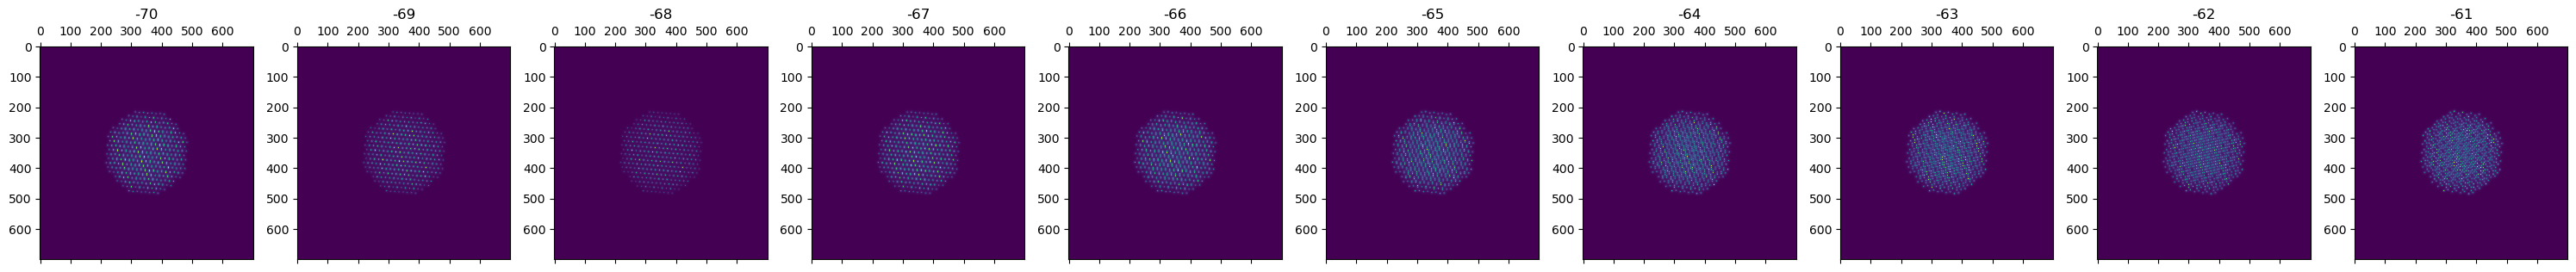

In [171]:
fig, ax = plt.subplots(figsize = (30, 10), ncols = 10)

for i, ax in enumerate(ax):
    ax.matshow(potentials_array[i].sum(axis = 0).get())
    ax.set_title(f'{tilt_angles[i]}')

plt.tight_layout()

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

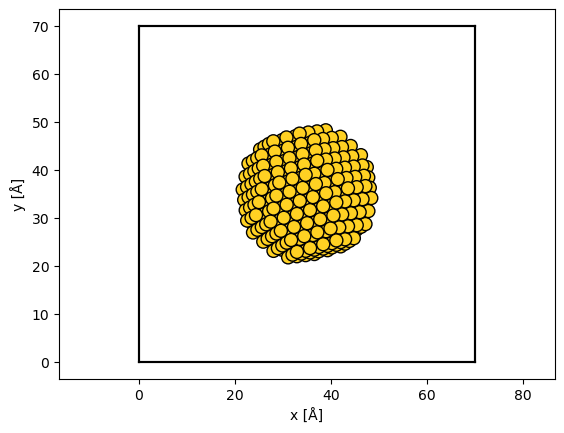

In [193]:
abtem.show_atoms(tilt_series[-10], scale = 1, plane = 'xy')

In [142]:
len(tilt_series)

139

In [145]:
len(np.arange(-70, 71, 1))

141

In [211]:
for i, tilt_state in enumerate(tilt_series):
    ase.io.write(f'../data/tilt_series_ase/tilt_{tilt_angles[i]}.xyz', tilt_state)

In [194]:
np.save('tilt_series.npy', tilt_series)

In [212]:
tilt_angles

array([-70, -69, -68, -67, -66, -65, -64, -63, -62, -61, -60, -59, -58,
       -57, -56, -55, -54, -53, -52, -51, -50, -49, -48, -47, -46, -45,
       -44, -43, -42, -41, -40, -39, -38, -37, -36, -35, -34, -33, -32,
       -31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19,
       -18, -17, -16, -15, -14, -13, -12, -11, -10,  -9,  -8,  -7,  -6,
        -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,   5,   6,   7,
         8,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,
        21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,
        34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,
        47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,
        60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70])

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

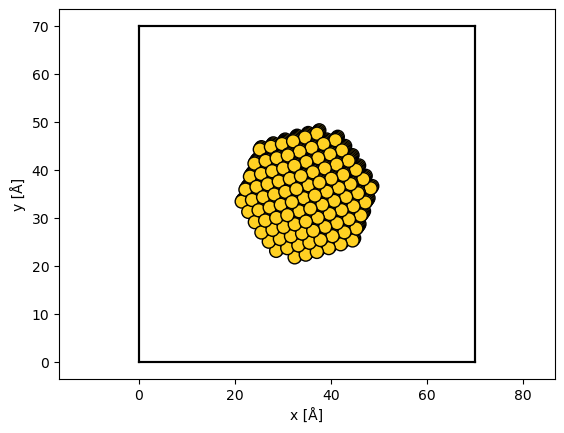

In [215]:
test = ase.io.read('../data/tilt_series_ase/tilt_25.xyz')
abtem.show_atoms(test, scale = 1, plane = 'xy')
